# Training mit Single Episode Datensatz

Dieses Notebook trainiert die **3 besten Algorithmen** aus dem Experiment "4 cumsum simulated every algo":

1. **BCQ** (diff_eval: 213.95) - Batch Constrained Q-learning
2. **PLAS** (diff_eval: 316.66) - Policy in Latent Action Space
3. **IQL** (diff_eval: 352.70) - Implicit Q-Learning

Trainingsdaten: `data/episFormula/8 single epi simulated` - Episoden mit einzelnen Bewässerungszyklen

In [1]:
import os
import csv

def read_Episodes(baseFolder):
    """Liest alle Episoden aus einem Ordner und gibt sie als Array zurück.
    Stoppt bei terminal == 1 (inklusive der ersten terminal=1 Zeile).
    """
    
    episodes = []
    headers = None
    terminal_index = None

    for filename in sorted(os.listdir(baseFolder)):
        filePath = os.path.join(baseFolder, filename)
        episode = []

        with open(filePath, "r", newline="") as file:
            reader = csv.reader(file)
            file_headers = next(reader)  # header lesen
            
            # Header initialisieren
            if headers is None:
                headers = file_headers
                terminal_index = headers.index('terminal')
            
            # CSV komplett einlesen
            rows = list(reader)
            last_index = len(rows) - 1
            
            for i, row in enumerate(rows):
                observation = [float(value) for value in row]
                observation[terminal_index] = 0
                # letzte Zeile → terminal=1
                if i == last_index:
                    observation[terminal_index] = 1
                episode.append(observation)
            episodes.append(episode)
       
    return episodes, headers

In [2]:
import d3rlpy
import numpy as np
import os
import random
from d3rlpy.optimizers import AdamFactory

# === DATENSATZ LADEN ===
EPIfolder = "../data/episFormula/8 single epi simulated"

epis, headers = read_Episodes(EPIfolder)

# Get column indices based on headers
obs_columns = ['doy', 'abstime', 'time', 'temp', 'humi', 'light', 'drain']
action_column = 'timeToIrri'
reward_column = 'reward'
terminal_column = 'terminal'
ideal_irri_column = 'idealIrri'

# Create index mappings
obs_indices = [headers.index(col) for col in obs_columns]
action_index = headers.index(action_column)
reward_index = headers.index(reward_column)
terminal_index = headers.index(terminal_column)
ideal_irri_index = headers.index(ideal_irri_column)

# Indices für einzelne Observations
doy_idx = headers.index('doy')
time_idx = headers.index('time')
temp_idx = headers.index('temp')
humi_idx = headers.index('humi')
light_idx = headers.index('light')
drain_idx = headers.index('drain')

print(f"Headers: {headers}")
print(f"Observation columns: {obs_columns} -> indices: {obs_indices}")
print(f"Action column: {action_column} -> index: {action_index}")
print(f"Reward column: {reward_column} -> index: {reward_index}")
print(f"Terminal column: {terminal_column} -> index: {terminal_index}")
print(f"IdealIrri column: {ideal_irri_column} -> index: {ideal_irri_index}")
print(f"Anzahl Episoden: {len(epis)}")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
c:\Users\NilsWindows\Desktop\research2.0\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Headers: ['doy', 'abstime', 'time', 'temp', 'humi', 'light', 'drain', 'timeToIrri', 'reward', 'terminal', 'idealIrri', 'evoCumsum']
Observation columns: ['doy', 'abstime', 'time', 'temp', 'humi', 'light', 'drain'] -> indices: [0, 1, 2, 3, 4, 5, 6]
Action column: timeToIrri -> index: 7
Reward column: reward -> index: 8
Terminal column: terminal -> index: 9
IdealIrri column: idealIrri -> index: 10
Anzahl Episoden: 35805


In [3]:
# === DATASET ERSTELLEN ===

def create_dataset_from_episodes(episodes, fraction=1.0):
    """Erstellt ein Dataset mit Basis-Observations (ohne Feature Engineering)."""
    random.seed(42)
    
    n_episodes = int(len(episodes) * fraction)
    selected_indices = random.sample(range(len(episodes)), n_episodes)
    selected_episodes = [episodes[i] for i in sorted(selected_indices)]
    
    observations = []
    actions = []
    rewards = []
    terminals = []
    
    for epi in selected_episodes:
        for row in epi:
            # Basis-Observations: doy, abstime, time, temp, humi, light, drain
            obs = [row[idx] for idx in obs_indices]
            observations.append(obs)
            
            # Action: timeToIrri
            action = row[action_index]
            actions.append([action])
            
            # Reward
            rewards.append(row[reward_index])
            
            # Terminal
            terminals.append(int(row[terminal_index]))
    
    observations = np.array(observations)
    actions = np.array(actions)
    rewards = np.array(rewards)
    terminals = np.array(terminals)
    
    dataset = d3rlpy.dataset.MDPDataset(
        action_space=d3rlpy.constants.ActionSpace.CONTINUOUS,
        observations=observations,
        actions=actions,
        rewards=rewards,
        terminals=terminals,
    )
    
    return dataset, observations, actions, rewards, terminals

# Dataset erstellen - nur 10% des Datensatzes verwenden
dataset, obs, acts, rews, terms = create_dataset_from_episodes(epis, fraction=1)

print(f"\n=== Dataset Statistiken ===")
print(f"Observations shape: {obs.shape}")
print(f"Observation columns: {obs_columns}")
print(f"Number of episodes: {len(dataset.episodes)}")
print(f"Rewards - Min: {rews.min():.2f}, Max: {rews.max():.2f}, Mean: {rews.mean():.2f}")
print(f"Actions - Min: {acts.min():.2f}, Max: {acts.max():.2f}")

2026-02-13 15:12.04 [info     ] Signatures have been automatically determined. action_signature=Signature(dtype=[dtype('float64')], shape=[(1,)]) observation_signature=Signature(dtype=[dtype('float64')], shape=[(7,)]) reward_signature=Signature(dtype=[dtype('float64')], shape=[(1,)])
2026-02-13 15:12.04 [info     ] Action size has been automatically determined. action_size=1

=== Dataset Statistiken ===
Observations shape: (859177, 7)
Observation columns: ['doy', 'abstime', 'time', 'temp', 'humi', 'light', 'drain']
Number of episodes: 35805
Rewards - Min: -1.00, Max: 1.00, Mean: -0.16
Actions - Min: -870.00, Max: 1010.00


In [4]:
# === TRAINING SETUP ===


# Scaler
action_scaler = d3rlpy.preprocessing.MinMaxActionScaler()
observation_scaler = d3rlpy.preprocessing.MinMaxObservationScaler()
reward_scaler = d3rlpy.preprocessing.StandardRewardScaler()

# Test-Episoden auswählen
random.seed(42)
test_episodes = []
n_test = min(500, len(dataset.episodes))
for i in range(n_test):
    test_episodes.append(dataset.episodes[random.randint(0, len(dataset.episodes)-1)])

print(f"Test-Episoden: {len(test_episodes)}")

# Logger
base_folder_name = os.path.basename(EPIfolder)
experiment_name = f"{base_folder_name}_top3_algos_final"

logger_adapter = d3rlpy.logging.CombineAdapterFactory([
   d3rlpy.logging.FileAdapterFactory(root_dir=f"logs/{experiment_name}/d3rlpy_logs"),
   #d3rlpy.logging.TensorboardAdapterFactory(root_dir=f"logs/{experiment_name}/tensorboard_logs"),
])

print(f"Log-Ordner: logs/{experiment_name}/")

Test-Episoden: 500
Log-Ordner: logs/8 single epi simulated_top3_algos_final/


In [5]:
# === MODELL 1: BCQ (Batch Constrained Q-learning) ===
# Hyperparameter basierend auf BESTEM Training (500k steps):
# - batch_size=23 (wie PLAS), gamma=0.99, kein reward_scaler, kein grad_clip
# - BCQ_20260209003014: 6023 → 2866 (200k) - mit kleinerer batch_size sollte es bei 500k noch besser werden

bcq_optim_factory = AdamFactory()  # Kein clip_grad_norm!

BCQ_model = d3rlpy.algos.BCQConfig(
    action_scaler=action_scaler,
    observation_scaler=observation_scaler,
    reward_scaler=None,              # KEIN Reward-Scaler!
    batch_size=23,                   # Wie PLAS (statt 32) - KRITISCH!
    gamma=0.99,                      # Höher wie bei bestem PLAS
    tau=0.005,                       # Target network update rate
    actor_learning_rate=1e-4,        # Niedriger für Stabilität
    critic_learning_rate=1e-3,       # Höher für schnelle Q-Schätzung
    imitator_learning_rate=1e-4,
    actor_optim_factory=bcq_optim_factory,
    critic_optim_factory=bcq_optim_factory,
    imitator_optim_factory=bcq_optim_factory,
    n_critics=2,
    lam=0.75,                        # Original Wert
    n_action_samples=100,            # Mehr Samples für bessere Q-Schätzung
    action_flexibility=0.05,         # Konservativer
    beta=0.5,                        # Original: ausgewogen
).create(device='cuda:0')

print("BCQ Modell konfiguriert (optimiert für 500k Training)")

BCQ Modell konfiguriert (optimiert für 500k Training)


In [6]:
# === MODELL 3: IQL (Implicit Q-Learning) ===
# Hyperparameter basierend auf BESTEM Training (500k steps):
# - batch_size=23 (wie PLAS), gamma=0.99, kein reward_scaler, kein grad_clip
# - IQL_20260210100213: 2622 → 2065 (200k) - mit 500k sollte es deutlich besser werden

iql_optim_factory = AdamFactory()  # Kein clip_grad_norm!

IQL_model = d3rlpy.algos.IQLConfig(
    action_scaler=action_scaler,
    observation_scaler=observation_scaler,
    reward_scaler=None,              # KEIN Reward-Scaler!
    batch_size=23,                   # Wie PLAS (statt 32) - KRITISCH!
    gamma=0.99,                      # Höher für bessere Long-Term Value
    tau=0.005,                       # Target network update rate
    actor_learning_rate=1e-4,        # Niedriger für Stabilität
    critic_learning_rate=1e-3,       # Höher für schnelle Q-Schätzung
    actor_optim_factory=iql_optim_factory,
    critic_optim_factory=iql_optim_factory,
    expectile=0.7,                   # Zurück auf Standardwert
    weight_temp=3.0,                 # Zurück auf Standardwert
).create(device='cuda:0')

print("IQL Modell konfiguriert (optimiert für 500k Training)")

IQL Modell konfiguriert (optimiert für 500k Training)


In [7]:
# === MODELL 2: PLAS (Policy in Latent Action Space) ===
# Hyperparameter basierend auf BESTEM Training (PLAS_20251123 - diff_eval ~500)

# WICHTIG: Separater Optimierer OHNE Gradient Clipping für PLAS
plas_optim_factory = AdamFactory()  # Kein clip_grad_norm!

PLAS_model = d3rlpy.algos.PLASConfig(
    action_scaler=action_scaler,
    observation_scaler=observation_scaler,
    reward_scaler=None,              # KEIN Reward-Scaler! (kritisch)
    batch_size=23,                   # Kleiner Batch funktioniert besser
    gamma=0.99,                      # Höher für bessere Long-Term Value
    tau=0.005,                       # Target network update rate
    actor_learning_rate=1e-4,        # Niedriger für Stabilität
    critic_learning_rate=1e-3,       # Höher für schnelle Q-Schätzung
    imitator_learning_rate=1e-4,     # Gleich wie Actor
    n_critics=2,
    lam=0.75,                        # Original Wert
    beta=0.5,                        # Original: höherer Constraint
    warmup_steps=500000,             # Wichtig für Stabilität!
).create(device='cuda:0')

print("PLAS Modell konfiguriert (basierend auf bestem Training)")

PLAS Modell konfiguriert (basierend auf bestem Training)


## Training starten

In [8]:
# === TRAINING ===

Models = [PLAS_model, IQL_model, BCQ_model]

for Model in Models:
    print(f"\n{'='*60}")
    print(f"Training: {Model.__class__.__name__}")
    print(f"{'='*60}")
    
    result = Model.fit(
        dataset,
        n_steps=1000000, #1000000 bei finaler messung dann
        n_steps_per_epoch=5000,
        evaluators={
            'td_error': d3rlpy.metrics.TDErrorEvaluator(test_episodes),
            'value_scale': d3rlpy.metrics.AverageValueEstimationEvaluator(test_episodes),
            'discounted_advantage': d3rlpy.metrics.DiscountedSumOfAdvantageEvaluator(test_episodes),
            'initial_state': d3rlpy.metrics.InitialStateValueEstimationEvaluator(test_episodes),
            'diff_eval': d3rlpy.metrics.ContinuousActionDiffEvaluator(test_episodes)
        },
        logger_adapter=logger_adapter,
    )
print(f"\n{'#'*80}")
print("# ALLE TRAININGS ABGESCHLOSSEN!")
print(f"{'#'*80}")


Training: PLAS
2026-02-13 15:12.06 [info     ] dataset info                   dataset_info=DatasetInfo(observation_signature=Signature(dtype=[dtype('float64')], shape=[(7,)]), action_signature=Signature(dtype=[dtype('float64')], shape=[(1,)]), reward_signature=Signature(dtype=[dtype('float64')], shape=[(1,)]), action_space=<ActionSpace.CONTINUOUS: 1>, action_size=1)
2026-02-13 15:12.06 [debug    ] Fitting observation scaler...  observation_scaler=min_max
2026-02-13 15:12.13 [debug    ] Fitting action scaler...       action_scaler=min_max
2026-02-13 15:12.20 [debug    ] Building models...            
2026-02-13 15:12.24 [debug    ] Models have been built.       
2026-02-13 15:12.24 [info     ] Directory is created at logs/8 single epi simulated_top3_algos_final/d3rlpy_logs\PLAS_20260213151224
2026-02-13 15:12.24 [info     ] Parameters                     params={'observation_shape': [7], 'action_size': 1, 'config': {'type': 'plas', 'params': {'batch_size': 23, 'gamma': 0.99, 'observati

Epoch 1/200: 100%|██████████| 5000/5000 [00:47<00:00, 105.94it/s, vae_loss=0.0042] 


2026-02-13 15:13.21 [info     ] PLAS_20260213151224: epoch=1 step=5000 epoch=1 metrics={'time_sample_batch': 0.0006059884071350097, 'time_algorithm_update': 0.008431525802612305, 'vae_loss': 0.004195536168885883, 'time_step': 0.009282557535171508, 'td_error': 0.3201251880395856, 'value_scale': 0.004271043066460271, 'discounted_advantage': 0.004691858003500386, 'initial_state': 0.009353469125926495, 'diff_eval': 2506.1035584886104} step=5000
2026-02-13 15:13.21 [info     ] Model parameters are saved to logs/8 single epi simulated_top3_algos_final/d3rlpy_logs\PLAS_20260213151224\model_5000.d3


Epoch 2/200: 100%|██████████| 5000/5000 [00:45<00:00, 109.78it/s, vae_loss=0.00326]


2026-02-13 15:14.16 [info     ] PLAS_20260213151224: epoch=2 step=10000 epoch=2 metrics={'time_sample_batch': 0.0005965538024902344, 'time_algorithm_update': 0.008100270462036133, 'vae_loss': 0.003261154970957432, 'time_step': 0.00894605507850647, 'td_error': 0.3199959711565186, 'value_scale': 0.004495620302654133, 'discounted_advantage': -0.0004938700160573724, 'initial_state': 0.009163537994027138, 'diff_eval': 2367.4426182366633} step=10000
2026-02-13 15:14.16 [info     ] Model parameters are saved to logs/8 single epi simulated_top3_algos_final/d3rlpy_logs\PLAS_20260213151224\model_10000.d3


...

2026-02-14 08:46.33 [info     ] BCQ_20260214005207: epoch=198 step=990000 epoch=198 metrics={'time_sample_batch': 0.000646065902709961, 'time_algorithm_update': 0.02513178234100342, 'vae_loss': 0.0016512332038022578, 'critic_loss': 20300254.566798437, 'actor_loss': -5855.389648486328, 'time_step': 0.026090469646453857, 'td_error': 8554231.792364994, 'value_scale': 4899.250287731747, 'discounted_advantage': -5420.848325924302, 'initial_state': 11031.41796875, 'diff_eval': 3103.0869018198578} step=990000
2026-02-14 08:46.33 [info     ] Model parameters are saved to logs/8 single epi simulated_top3_algos_final/d3rlpy_logs\BCQ_20260214005207\model_990000.d3


Epoch 199/200: 100%|██████████| 5000/5000 [02:05<00:00, 39.77it/s, vae_loss=0.00162, critic_loss=1.37e+7, actor_loss=-4.82e+3]


2026-02-14 08:48.52 [info     ] BCQ_20260214005207: epoch=199 step=995000 epoch=199 metrics={'time_sample_batch': 0.0006094617366790772, 'time_algorithm_update': 0.023822386837005615, 'vae_loss': 0.0016202698440785752, 'critic_loss': 13715927.49811172, 'actor_loss': -4813.994581591797, 'time_step': 0.02472701368331909, 'td_error': 5252657.69992964, 'value_scale': 4719.771498904447, 'discounted_advantage': -5859.96584736287, 'initial_state': 11233.2724609375, 'diff_eval': 2837.9730082955984} step=995000
2026-02-14 08:48.52 [info     ] Model parameters are saved to logs/8 single epi simulated_top3_algos_final/d3rlpy_logs\BCQ_20260214005207\model_995000.d3


Epoch 200/200: 100%|██████████| 5000/5000 [02:05<00:00, 39.89it/s, vae_loss=0.00164, critic_loss=7.9e+6, actor_loss=-4.17e+3] 


2026-02-14 08:51.11 [info     ] BCQ_20260214005207: epoch=200 step=1000000 epoch=200 metrics={'time_sample_batch': 0.0006260156154632568, 'time_algorithm_update': 0.02368226418495178, 'vae_loss': 0.001636145735712489, 'critic_loss': 7911566.528551563, 'actor_loss': -4166.7382828125, 'time_step': 0.024620463562011717, 'td_error': 4703345.533087314, 'value_scale': 4904.461808980745, 'discounted_advantage': -5942.132874445447, 'initial_state': 8552.6376953125, 'diff_eval': 3016.938599518005} step=1000000
2026-02-14 08:51.11 [info     ] Model parameters are saved to logs/8 single epi simulated_top3_algos_final/d3rlpy_logs\BCQ_20260214005207\model_1000000.d3

################################################################################
# ALLE TRAININGS ABGESCHLOSSEN!
################################################################################


## Trainings-Analyse

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Lade Log-Dateien für Analyse
log_base = f"logs/{experiment_name}/d3rlpy_logs_500k"

# Finde die Log-Ordner
if os.path.exists(log_base):
    log_folders = [f for f in os.listdir(log_base) if os.path.isdir(os.path.join(log_base, f))]
    print(f"Gefundene Log-Ordner: {log_folders}")
else:
    print(f"Log-Ordner nicht gefunden: {log_base}")
    log_folders = []

Gefundene Log-Ordner: ['BCQ_20260213030307', 'IQL_20260213001109', 'PLAS_20260212223013']


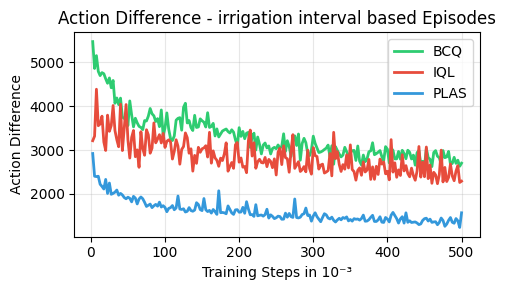

In [21]:
# Visualisierung der Trainings-Ergebnisse
if log_folders:
    fig, axes = plt.subplots(1, 1, figsize=(5, 3))
    colors = {'BCQ': '#2ecc71', 'PLAS': '#3498db', 'IQL': '#e74c3c'}
    
    for folder in log_folders:
        model_name = folder.split('_')[0]
        color = colors.get(model_name, '#999999')
        
        # diff_eval laden
        diff_path = os.path.join(log_base, folder, 'diff_eval.csv')
        if os.path.exists(diff_path):
            df = pd.read_csv(diff_path, header=None, names=['epoch', 'step', 'value'])
            axes.plot(df['step']/1000, df['value'], label=model_name, color=color, linewidth=2)
    
    axes.set_xlabel('Training Steps in 10⁻³')
    axes.set_title('Action Difference - irrigation interval based Episodes')
    axes.set_ylabel('Action Difference')
    axes.legend()
    axes.grid(True, alpha=0.3)
    
    
    plt.tight_layout()
    plt.savefig(f'logs/{experiment_name}/training_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Keine Log-Daten gefunden. Führe zuerst das Training aus.")

In [15]:
# Zusammenfassung der Ergebnisse
print("="*80)
print("ZUSAMMENFASSUNG DER TRAININGS-ERGEBNISSE")
print("="*80)

if log_folders:
    results = []
    for folder in log_folders:
        model_name = folder.split('_')[0]
        
        # diff_eval final value
        diff_path = os.path.join(log_base, folder, 'diff_eval.csv')
        if os.path.exists(diff_path):
            df = pd.read_csv(diff_path, header=None, names=['epoch', 'step', 'value'])
            diff_final = df['value'].iloc[-1]
            diff_min = df['value'].min()
        else:
            diff_final = float('inf')
            diff_min = float('inf')
        
        results.append({
            'Model': model_name,
            'Action Diff (final)': diff_final,
            'Action Diff (min)': diff_min
        })
    
    df_results = pd.DataFrame(results)
    df_sorted = df_results.sort_values('Action Diff (final)')
    
    print("\nRanking nach Action Diff (niedriger = besser):")
    for i, (_, row) in enumerate(df_sorted.iterrows(), 1):
        medal = ['1.', '2.', '3.'][i-1] if i <= 3 else f'{i}.'
        print(f"   {medal} {row['Model']}: Final={row['Action Diff (final)']:.0f}, Min={row['Action Diff (min)']:.0f}")
else:
    print("Keine Ergebnisse verfügbar.")

ZUSAMMENFASSUNG DER TRAININGS-ERGEBNISSE

Ranking nach Action Diff (niedriger = besser):
   1. PLAS: Final=233, Min=231
   2. PLAS: Final=1560, Min=1542
   3. IQL: Final=2138, Min=1915
   4. BCQ: Final=2866, Min=2425
   5. CQL: Final=inf, Min=inf
